# Sentiment Analysis — VADER vs RoBERTa
Comparing two pretrained sentiment approaches on synthetic Reddit religion posts with known labels.

In [8]:
import nltk
import pandas as pd
from IPython.display import display

nltk.download('vader_lexicon', quiet=True)

True

## Synthetic posts
15 posts — 5 positive, 5 negative, 5 neutral. Labels are ground truth.

In [9]:
synthetic_posts = [
    # --- POSITIVE ---
    {"label": "positive", "text": "I feel so at peace after attending church today. The sermon really spoke to my heart and I left feeling genuinely uplifted."},
    {"label": "positive", "text": "Finally found a faith community that accepts me completely. I've never felt more welcomed and loved in my entire life."},
    {"label": "positive", "text": "Honestly prayer has changed my life. I was in a really dark place last year and my faith carried me through. Grateful every single day."},
    {"label": "positive", "text": "Buddhism has helped me become so much calmer and more compassionate. The teachings on impermanence really freed me from a lot of anxiety."},
    {"label": "positive", "text": "Just got back from Hajj and I'm still overwhelmed with joy and gratitude. It was the most spiritually fulfilling experience of my life."},

    # --- NEGATIVE ---
    {"label": "negative", "text": "Religion is just a tool for controlling people. Can't believe anyone still falls for this nonsense in 2024."},
    {"label": "negative", "text": "My church completely abandoned me when I came out. These people preached love every Sunday and then dropped me instantly. Hypocrites."},
    {"label": "negative", "text": "So sick and tired of religious people forcing their beliefs on everyone around them. Keep it to yourselves. Not everyone shares your fairy tales."},
    {"label": "negative", "text": "The amount of trauma and guilt that organized religion gave me as a kid is genuinely unbelievable. Took years of therapy to undo."},
    {"label": "negative", "text": "These megachurches are just predatory scams bleeding vulnerable people dry. Prosperity gospel should be illegal."},

    # --- NEUTRAL ---
    {"label": "neutral", "text": "What are the main theological differences between Sunni and Shia Islam?"},
    {"label": "neutral", "text": "Does anyone know when Ramadan starts this year? I keep seeing different dates."},
    {"label": "neutral", "text": "Both Catholic and Protestant traditions trace their core doctrine back to the Nicene Creed of 325 AD."},
    {"label": "neutral", "text": "The Book of Mormon was first published in 1830 by Joseph Smith in Palmyra, New York."},
    {"label": "neutral", "text": "Curious — how many of you were raised religious versus came to faith later as adults?"},
]

## VADER
Rule-based lexicon approach from NLTK. Designed for social media text. Instant, no model download.

In [10]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_label(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    return "neutral"

vader_rows = []
for post in synthetic_posts:
    compound = sia.polarity_scores(post["text"])["compound"]
    pred = vader_label(compound)
    vader_rows.append({
        "true": post["label"],
        "vader": pred,
        "compound": round(compound, 3),
        "correct": pred == post["label"],
        "text": post["text"][:70] + "...",
    })

df_vader = pd.DataFrame(vader_rows)

def highlight_wrong(row):
    color = "" if row["correct"] else "background-color: #ff0000"
    return [color] * len(row)

display(df_vader.style.apply(highlight_wrong, axis=1))
print(f"VADER accuracy: {df_vader['correct'].mean():.0%}  ({df_vader['correct'].sum()}/{len(df_vader)})")

,true,vader,compound,correct,text
0,positive,positive,0.646000,True,I feel so at peace after attending church today. The sermon really spo...
1,positive,positive,0.791000,True,Finally found a faith community that accepts me completely. I've never...
2,positive,positive,0.832000,True,Honestly prayer has changed my life. I was in a really dark place last...
3,positive,positive,0.821000,True,Buddhism has helped me become so much calmer and more compassionate. T...
4,positive,positive,0.807000,True,Just got back from Hajj and I'm still overwhelmed with joy and gratitu...
5,negative,negative,-0.481000,True,Religion is just a tool for controlling people. Can't believe anyone s...
6,negative,positive,0.228000,False,My church completely abandoned me when I came out. These people preach...
7,negative,negative,-0.825000,True,So sick and tired of religious people forcing their beliefs on everyon...
8,negative,negative,-0.477000,True,The amount of trauma and guilt that organized religion gave me as a ki...
9,negative,negative,-0.852000,True,These megachurches are just predatory scams bleeding vulnerable people...


VADER accuracy: 87%  (13/15)


## RoBERTa (Cardiff NLP)
`cardiffnlp/twitter-roberta-base-sentiment-latest` — trained on ~124M tweets. Downloads ~500MB on first run.

In [11]:
from transformers import pipeline

pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
)

texts = [p["text"] for p in synthetic_posts]
raw = pipe(texts, batch_size=8)

roberta_rows = []
for post, res in zip(synthetic_posts, raw):
    pred = res["label"]  # model returns 'positive'/'neutral'/'negative' directly
    roberta_rows.append({
        "true": post["label"],
        "roberta": pred,
        "score": round(res["score"], 3),
        "correct": pred == post["label"],
        "text": post["text"][:70] + "...",
    })

df_roberta = pd.DataFrame(roberta_rows)
display(df_roberta.style.apply(highlight_wrong, axis=1))
print(f"RoBERTa accuracy: {df_roberta['correct'].mean():.0%}  ({df_roberta['correct'].sum()}/{len(df_roberta)})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,true,roberta,score,correct,text
0,positive,positive,0.983000,True,I feel so at peace after attending church today. The sermon really spo...
1,positive,positive,0.980000,True,Finally found a faith community that accepts me completely. I've never...
2,positive,positive,0.964000,True,Honestly prayer has changed my life. I was in a really dark place last...
3,positive,positive,0.936000,True,Buddhism has helped me become so much calmer and more compassionate. T...
4,positive,positive,0.989000,True,Just got back from Hajj and I'm still overwhelmed with joy and gratitu...
5,negative,negative,0.936000,True,Religion is just a tool for controlling people. Can't believe anyone s...
6,negative,negative,0.928000,True,My church completely abandoned me when I came out. These people preach...
7,negative,negative,0.885000,True,So sick and tired of religious people forcing their beliefs on everyon...
8,negative,negative,0.935000,True,The amount of trauma and guilt that organized religion gave me as a ki...
9,negative,negative,0.940000,True,These megachurches are just predatory scams bleeding vulnerable people...


RoBERTa accuracy: 100%  (15/15)


## Head-to-head comparison

In [12]:
comparison = pd.DataFrame({
    "text":    [p["text"][:70] + "..." for p in synthetic_posts],
    "true":    [p["label"] for p in synthetic_posts],
    "vader":   df_vader["vader"],
    "roberta": df_roberta["roberta"],
    "vader_ok":   df_vader["correct"],
    "roberta_ok": df_roberta["correct"],
})

# Both wrong
both_wrong = comparison[~comparison["vader_ok"] & ~comparison["roberta_ok"]]
# Disagree
disagree = comparison[comparison["vader"] != comparison["roberta"]]

print("=== Summary ===")
print(f"VADER accuracy:   {df_vader['correct'].mean():.0%}")
print(f"RoBERTa accuracy: {df_roberta['correct'].mean():.0%}")
print(f"Both wrong: {len(both_wrong)}")
print(f"Disagree:   {len(disagree)}")

if len(disagree):
    print("\n=== Cases where they disagree ===")
    display(disagree[["text", "true", "vader", "roberta"]].reset_index(drop=True))

if len(both_wrong):
    print("\n=== Cases where both are wrong ===")
    display(both_wrong[["text", "true", "vader", "roberta"]].reset_index(drop=True))

=== Summary ===
VADER accuracy:   87%
RoBERTa accuracy: 100%
Both wrong: 0
Disagree:   2

=== Cases where they disagree ===


,text,true,vader,roberta
0,My church completely abandoned me when I came ...,negative,positive,negative
1,Curious — how many of you were raised religiou...,neutral,positive,neutral


In [13]:
for text in disagree.text.values:
    print(text)
    print()

My church completely abandoned me when I came out. These people preach...

Curious — how many of you were raised religious versus came to faith l...



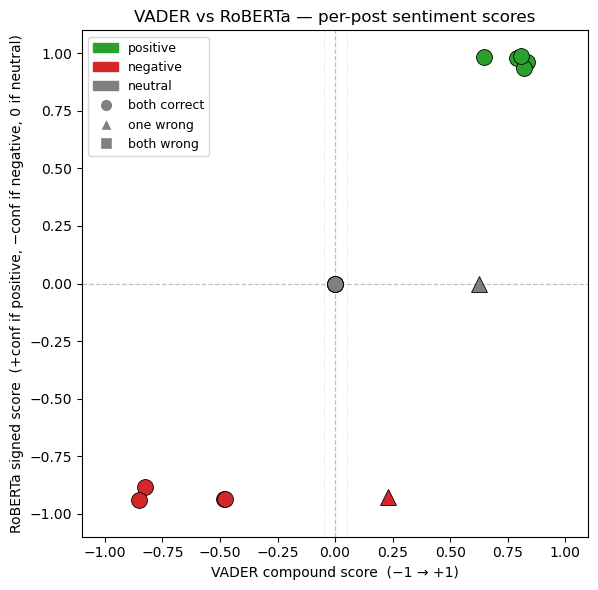

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

color_map = {"positive": "#2ca02c", "negative": "#d62728", "neutral": "#7f7f7f"}

# Convert RoBERTa confidence to signed score so it's on the same -1..1 axis as VADER
roberta_signed = [
    row["score"]  if row["roberta"] == "positive" else
    -row["score"] if row["roberta"] == "negative" else 0.0
    for _, row in df_roberta.iterrows()
]

fig, ax = plt.subplots(figsize=(7, 6))

for i, post in enumerate(synthetic_posts):
    x = df_vader.loc[i, "compound"]
    y = roberta_signed[i]
    both_ok  = df_vader.loc[i, "correct"] and df_roberta.loc[i, "correct"]
    both_bad = not df_vader.loc[i, "correct"] and not df_roberta.loc[i, "correct"]
    marker = "o" if both_ok else ("s" if both_bad else "^")
    ax.scatter(x, y, color=color_map[post["label"]], marker=marker,
               s=130, zorder=3, edgecolors="black", linewidths=0.6)

# quadrant lines
ax.axvline(0,     color="gray", lw=0.9, ls="--", alpha=0.5)
ax.axhline(0,     color="gray", lw=0.9, ls="--", alpha=0.5)
# VADER decision thresholds
ax.axvline( 0.05, color="gray", lw=0.5, ls=":",  alpha=0.4)
ax.axvline(-0.05, color="gray", lw=0.5, ls=":",  alpha=0.4)

ax.set_xlabel("VADER compound score  (−1 → +1)")
ax.set_ylabel("RoBERTa signed score  (+conf if positive, −conf if negative, 0 if neutral)")
ax.set_title("VADER vs RoBERTa — per-post sentiment scores")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")

color_legend  = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
marker_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9, label="both correct"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="gray", markersize=9, label="one wrong"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9, label="both wrong"),
]
ax.legend(handles=color_legend + marker_legend, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()